Imports

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report


Dataset Extraction

In [ ]:
zip_file_path = '/content/lake_bird_images.zip'
extract_path = '/content/lake_bird_images'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")


Dataset extracted successfully.


## Dataset Paths

The dataset contains separate folders for training and testing images.


In [ ]:
BASE_DIR = '/content/lake_bird_images/lake_bird_images'

train_dir = os.path.join(BASE_DIR, 'train')
test_dir  = os.path.join(BASE_DIR, 'test')

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))


Train folders: ['goose', 'swan', 'duck']
Test folders: ['goose', 'swan', 'duck']


## Data Generator Configuration

This section defines image preprocessing, normalisation, and dataset splitting.


In [ ]:
# Reproducibility
SEED = 42

# Image configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data generator with augmentation + validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Test data generator (NO augmentation)
test_datagen = ImageDataGenerator(
    rescale=1./255
)


## Image Preprocessing and Data Augmentation

ImageDataGenerator is used to apply real-time data augmentation and to split the training data into training and validation subsets.


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1452 images belonging to 3 classes.
Found 362 images belonging to 3 classes.
Found 783 images belonging to 3 classes.


Model Architecture

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Model Compilation

The model is compiled using the Adam optimiser and categorical cross-entropy loss.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Training Configuration

Early stopping is applied to prevent overfitting by monitoring validation loss.


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


## Model Training


In [ ]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.3735 - loss: 1.7087 - val_accuracy: 0.5856 - val_loss: 0.8836
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 433ms/step - accuracy: 0.6477 - loss: 0.9586 - val_accuracy: 0.6878 - val_loss: 0.7236
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 451ms/step - accuracy: 0.6731 - loss: 0.8314 - val_accuracy: 0.7376 - val_loss: 0.6529
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 452ms/step - accuracy: 0.7351 - loss: 0.7158 - val_accuracy: 0.7845 - val_loss: 0.5951
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 437ms/step - accuracy: 0.7689 - loss: 0.6199 - val_accuracy: 0.7597 - val_loss: 0.5851
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 438ms/step - accuracy: 0.7748 - loss: 0.6070 - val_accuracy: 0.7983 - val_loss: 0.5720
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 453ms/step - accuracy: 0.7857 - loss: 0.5854 - val_accuracy: 0.7928 - val_loss: 0.5984
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 451ms/step - accuracy: 0.8014 - loss: 0.5331 - val_accurac

## Training and Validation Performance

The learning curves show steady improvement in training accuracy, with validation accuracy stabilising around 82%. In training, the validation loss at first has a decreasing trend, before leveling off, which is an indicator of successful regularisation.


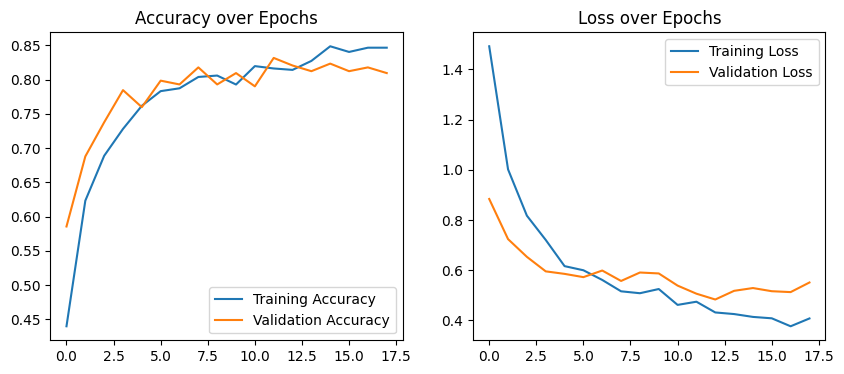

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.show()


## Evaluation on Test Data

The trained model is tested on a held-out test set in order to determine the performance of generalisation.


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.3f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 458ms/step - accuracy: 0.7955 - loss: 0.5331
Test accuracy: 0.831


## Confusion Matrix Analysis

The confusion matrix highlights strong classification performance across all classes, with minor confusion between ducks and geese.


25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 213ms/step


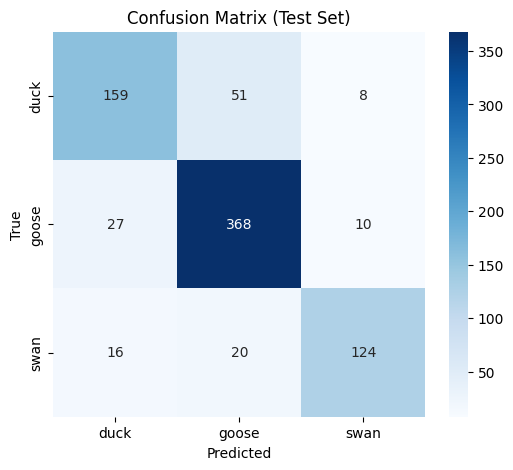

In [ ]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.show()


## Classification Metrics

Precision, recall, and F1-score indicate balanced performance across classes, with geese achieving the highest recall.


In [ ]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))


              precision    recall  f1-score   support

        duck       0.79      0.73      0.76       218
       goose       0.84      0.91      0.87       405
        swan       0.87      0.78      0.82       160

    accuracy                           0.83       783
   macro avg       0.83      0.80      0.82       783
weighted avg       0.83      0.83      0.83       783



##Results and Discussion
##Performance of the Model

The performance of the convolutional neural network was evaluated using training and validation learning curves, a confusion matrix, and class-wise precision, recall, and F1-scores on the held-out test dataset.

Figure 1 shows the training and validation accuracy and loss over epochs. Training accuracy increases steadily from approximately 45% to around 85%, while validation accuracy follows a similar trend, stabilising at approximately 82–83%. This indicates that the model successfully learns discriminative visual features from the training data and generalises reasonably well to unseen validation data. The relatively small gap between training and validation accuracy suggests that severe overfitting is avoided, which can be attributed to the use of dropout, batch normalisation, early stopping, and transfer learning with a frozen MobileNetV2 backbone.

The loss curves further support this observation. Training loss decreases consistently throughout training, while validation loss initially decreases and then stabilises, with minor fluctuations towards later epochs. This behaviour suggests diminishing returns from additional training rather than divergence, indicating that early stopping was appropriately configured to prevent overfitting.

Evaluation on the unseen test set resulted in an overall accuracy of approximately 83%, which is substantially higher than the random baseline of 33% for a three-class classification problem. This confirms that the model generalises effectively beyond the training and validation sets.

To support stable training and improve generalisation, several key hyperparameters were selected empirically. The Adam optimiser was used with a learning rate of
1
×
10
−
4
1×10
−4
, which provided a good balance between convergence speed and training stability when fine-tuning the classifier layers. A dropout rate of 0.5 was applied to the fully connected layer to reduce overfitting by randomly deactivating neurons during training. In addition, early stopping with a patience of five epochs was employed to halt training once the validation loss stopped improving, preventing unnecessary training and limiting overfitting.

Figure 2 presents the confusion matrix for the test dataset. The model performs strongest on the goose class, which achieves the highest number of correct predictions. This is likely due to the larger number of goose images in the training data, allowing the model to learn more robust representations for this class. Ducks and swans also show strong performance, although some confusion exists between ducks and geese, likely due to visual similarities such as body shape and colour in certain lighting conditions.

Class-wise precision, recall, and F1-scores are summarized in Figure 3. The majority of goose photos are properly identified, as evidenced by their highest recall (0.91). Swans have high precision (0.87), indicating that the model is typically accurate when it predicts “swan.”
The slightly lower recall of ducks suggests that some duck photos are mistakenly identified as geese. In general, the weighted F1-score of approximately 0.83 reflects balanced performance across classes.

Despite class imbalance, a score of about 0.83 indicates balanced performance across classes.

##Limitations
The model performs well, but its precision is constrained by a number of parameters.

First, performance is impacted by the dataset’s class imbalance. The program is biased to predict geese with more confidence because the goose class has a lot more photos than ducks and swans. The confusion matrix and the increased recall for geese in contrast to ducks and swans both demonstrate this.

Second, discriminative performance is limited by visual similarity between classes. Depending on the attitude, lighting, and distance from the camera, ducks and geese may appear visually identical, which could result in incorrect classifications. The dataset itself has this constraint, not just the model design.

Third, because the model employs a frozen feature extractor (MobileNetV2), the lake bird dataset is not used to fine-tune the convolutional layers. This may limit the model’s capacity to learn highly specialized features specific to this particular environment, even as it increases training stability and decreases overfitting.

##Conclusion
In this work, photos of ducks, geese, and swans were effectively classified using a deep convolutional neural network based on MobileNetV2. With a test accuracy of roughly 83% and balanced precision and recall across classes, the model demonstrated outstanding generalization performance. The confusion matrix shows both strengths and class-specific difficulties, while the training and validation curves show steady learning without significant overfitting. Although limited fine-tuning, visual similarity between species, and class imbalance limit performance, the results show that transfer learning in conjunction with suitable regularization can generate reliable multiclass image classifiers.